# Exploratory data analysis

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading & Basic Inspection

In [57]:
df = pd.read_csv("../data/baltic_prices.csv", index_col="Date", parse_dates=True)
df.head()

,AKO1L.VS,APG1L.VS,ARC1T.TL,CPA1T.TL,DGR1R.RG,EEG1T.TL,EFT1T.TL,GRG1L.VS,HAE1T.TL,IGN1L.VS,LHV1T.TL,MRK1T.TL,NCN1T.TL,NTU1L.VS,PKG1T.TL
Date,,,,,,,,,,,,,,,
2021-01-04,0.610417,1.079082,1.079360,1.088082,NaN,0.623248,15.258244,0.491755,4.814266,15.360378,1.918030,6.853395,1.046326,3.00,0.705
2021-01-05,0.605994,1.063841,1.096630,1.097165,NaN,0.627168,15.258244,0.493590,5.029830,15.251439,2.035093,7.025807,1.037228,2.96,0.705
2021-01-06,0.610417,1.066889,1.113899,1.135311,NaN,0.623248,15.337713,0.493590,5.119648,15.251439,2.062107,7.169484,1.056436,2.96,0.705
2021-01-07,0.623687,1.060793,1.122534,1.131678,NaN,0.627168,15.337713,0.510104,4.940012,15.251439,2.089122,7.169484,1.046832,3.00,0.705
2021-01-08,0.641381,1.042504,1.122534,1.122596,NaN,0.627168,15.417183,0.530288,4.922048,15.578258,2.116136,7.155117,1.056436,2.98,0.700


In [58]:
df.tail()

,AKO1L.VS,APG1L.VS,ARC1T.TL,CPA1T.TL,DGR1R.RG,EEG1T.TL,EFT1T.TL,GRG1L.VS,HAE1T.TL,IGN1L.VS,LHV1T.TL,MRK1T.TL,NCN1T.TL,NTU1L.VS,PKG1T.TL
Date,,,,,,,,,,,,,,,
2026-03-27,1.58,3.47,1.505,2.230,1.380,1.23,19.700001,1.050,5.68,21.400000,3.565,27.049999,0.580,0.930,0.92
2026-03-30,1.54,3.52,1.505,2.230,1.372,1.23,19.700001,1.045,5.68,21.350000,3.565,27.049999,0.580,0.918,0.92
2026-03-31,1.55,3.53,1.500,2.235,1.386,1.23,19.799999,1.050,5.60,21.350000,3.550,27.100000,0.580,0.900,0.92
2026-04-01,1.58,3.59,1.505,2.245,1.410,1.23,19.650000,1.050,5.62,21.350000,3.550,27.250000,0.617,0.900,0.92
2026-04-02,1.58,3.61,1.500,2.250,1.406,1.23,19.850000,1.055,5.60,21.549999,3.550,27.000000,0.609,0.882,0.92


In [59]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1331 entries, 2021-01-04 to 2026-04-02
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   AKO1L.VS  1307 non-null   float64
 1   APG1L.VS  1307 non-null   float64
 2   ARC1T.TL  1319 non-null   float64
 3   CPA1T.TL  1319 non-null   float64
 4   DGR1R.RG  1103 non-null   float64
 5   EEG1T.TL  1319 non-null   float64
 6   EFT1T.TL  1319 non-null   float64
 7   GRG1L.VS  1307 non-null   float64
 8   HAE1T.TL  1319 non-null   float64
 9   IGN1L.VS  1307 non-null   float64
 10  LHV1T.TL  1319 non-null   float64
 11  MRK1T.TL  1319 non-null   float64
 12  NCN1T.TL  1319 non-null   float64
 13  NTU1L.VS  1307 non-null   float64
 14  PKG1T.TL  1319 non-null   float64
dtypes: float64(15)
memory usage: 166.4 KB


In [60]:
print(f"Shape: {df.shape}")  # expect ~1300 rows × 15 columns
print()
print(df.dtypes)
print()
print(f"Date range: {df.index.min()} to {df.index.max()}")

Shape: (1331, 15)

AKO1L.VS    float64
APG1L.VS    float64
ARC1T.TL    float64
CPA1T.TL    float64
DGR1R.RG    float64
EEG1T.TL    float64
EFT1T.TL    float64
GRG1L.VS    float64
HAE1T.TL    float64
IGN1L.VS    float64
LHV1T.TL    float64
MRK1T.TL    float64
NCN1T.TL    float64
NTU1L.VS    float64
PKG1T.TL    float64
dtype: object

Date range: 2021-01-04 00:00:00 to 2026-04-02 00:00:00


## 2. Data Quality

In [61]:

df.loc["2023"].head(5)

,AKO1L.VS,APG1L.VS,ARC1T.TL,CPA1T.TL,DGR1R.RG,EEG1T.TL,EFT1T.TL,GRG1L.VS,HAE1T.TL,IGN1L.VS,LHV1T.TL,MRK1T.TL,NCN1T.TL,NTU1L.VS,PKG1T.TL
Date,,,,,,,,,,,,,,,
2023-01-02,1.215163,1.63152,1.663738,2.268984,1.200976,1.324571,16.561081,0.594817,4.676728,15.607603,3.117248,11.675851,0.678,2.970,0.602
2023-01-03,1.228765,1.63918,1.663738,2.296543,1.204213,1.315885,16.561081,0.601519,4.676728,15.656842,3.117248,11.773967,0.685,2.970,0.600
2023-01-04,1.251436,1.64684,1.660098,2.272658,1.207451,1.307200,16.561081,0.608222,4.751555,15.607603,3.135803,11.773967,0.680,2.950,0.596
2023-01-05,1.278641,1.63918,1.638255,2.274496,1.209069,1.311543,16.561081,0.609897,4.676728,15.607603,3.145081,11.806672,0.695,2.943,0.596
2023-01-06,1.269573,1.65450,1.638255,2.261635,1.210688,1.320228,16.561081,0.611573,4.742202,15.607603,3.140442,11.855731,0.700,2.942,0.600


### 2a. Missing Values

In [62]:
nan_counts = df.isnull().sum()
nan_pct = df.isnull().sum() / len(df) * 100

missing = pd.DataFrame({"NaN count": nan_counts, "NaN %": nan_pct.round(2)})
print(missing.sort_values("NaN %", ascending=False))
print()
flagged = nan_pct[nan_pct > 5].index.tolist()
print(f"Tickers with >5% missing: {flagged}")

          NaN count  NaN %
DGR1R.RG        228  17.13
APG1L.VS         24   1.80
AKO1L.VS         24   1.80
IGN1L.VS         24   1.80
NTU1L.VS         24   1.80
GRG1L.VS         24   1.80
ARC1T.TL         12   0.90
EFT1T.TL         12   0.90
EEG1T.TL         12   0.90
CPA1T.TL         12   0.90
HAE1T.TL         12   0.90
LHV1T.TL         12   0.90
MRK1T.TL         12   0.90
NCN1T.TL         12   0.90
PKG1T.TL         12   0.90

Tickers with >5% missing: ['DGR1R.RG']


### 2b. Missing Value Pattern

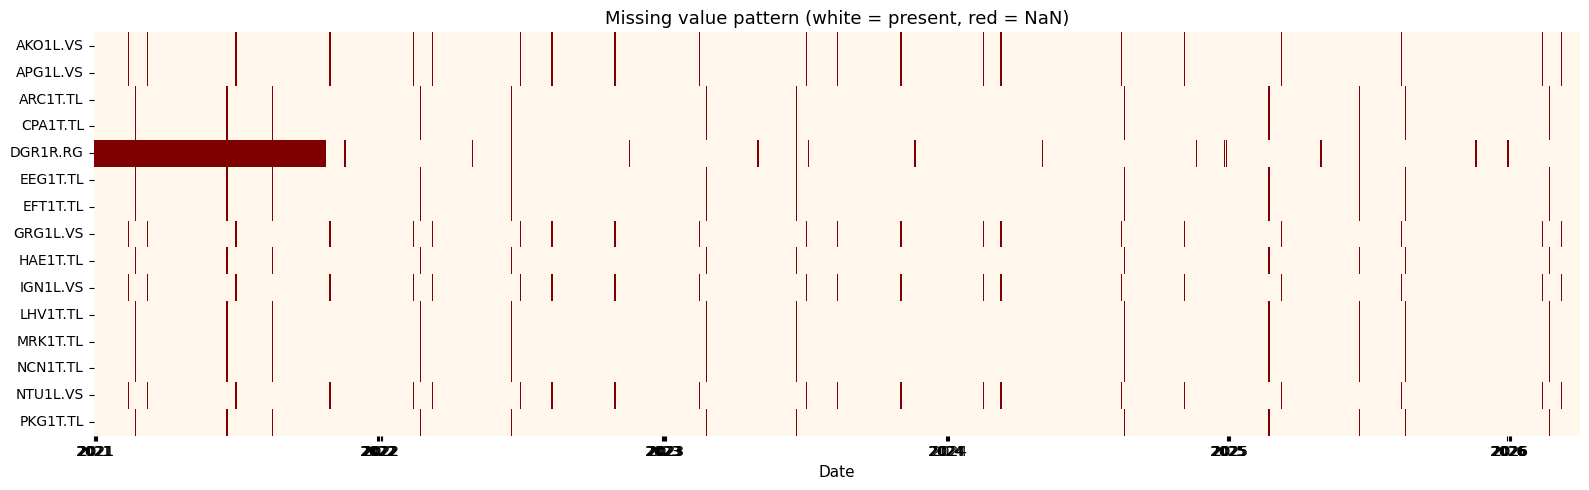

DGR1R.RG: first valid date = 2021-10-27 00:00:00


In [63]:
fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(df.isnull().T, cbar=False, yticklabels=True, ax=ax, cmap="OrRd")
ax.set_title("Missing value pattern (white = present, red = NaN)", fontsize=13)
ax.set_xlabel("Date", fontsize=11)
ax.tick_params(axis="y", labelsize=10)

# Show only yearly x-tick labels instead of every date
yearly_ticks = [i for i, d in enumerate(df.index) if d.month == 1 and d.day <= 7]
ax.set_xticks(yearly_ticks)
ax.set_xticklabels([df.index[i].year for i in yearly_ticks], rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

# Are NaNs clustered at the start (late listing) or scattered?
for ticker in flagged:
    first_valid = df[ticker].first_valid_index()
    print(f"{ticker}: first valid date = {first_valid}")

### 2c. Trading Calendar Gaps

In [64]:
gap_counts = df.index.to_series().diff().dt.days.value_counts().sort_index()
print("Days between consecutive trading dates:")
print(gap_counts)
print()
# Most gaps should be 1 (consecutive days) or 3 (Friday→Monday)
unusual = gap_counts[gap_counts.index > 3]
if not unusual.empty:
    print("Unusual gaps (>3 days):")
    print(unusual)

Days between consecutive trading dates:
Date
1.0    1045
2.0       9
3.0     261
4.0       8
5.0       6
6.0       1
Name: count, dtype: int64

Unusual gaps (>3 days):
Date
4.0    8
5.0    6
6.0    1
Name: count, dtype: int64


### 2d. Stale Prices (Flat Lines)

In [65]:
stale = (df.diff() == 0).sum()
stale_pct = (stale / len(df) * 100).round(2)

stale_df = pd.DataFrame({"Zero-change days": stale, "% of days": stale_pct})
print(stale_df.sort_values("Zero-change days", ascending=False))
print()
# Flag tickers with high stale rate — signals illiquid/thinly traded stock
stale_flagged = stale_pct[stale_pct > 20].index.tolist()
print(f"Tickers with >20% stale days: {stale_flagged}")

          Zero-change days  % of days
EFT1T.TL               456      34.26
PKG1T.TL               357      26.82
APG1L.VS               333      25.02
EEG1T.TL               330      24.79
GRG1L.VS               320      24.04
AKO1L.VS               311      23.37
IGN1L.VS               285      21.41
DGR1R.RG               281      21.11
ARC1T.TL               255      19.16
NCN1T.TL               239      17.96
HAE1T.TL               216      16.23
NTU1L.VS               195      14.65
MRK1T.TL               188      14.12
LHV1T.TL               162      12.17
CPA1T.TL               157      11.80

Tickers with >20% stale days: ['AKO1L.VS', 'APG1L.VS', 'DGR1R.RG', 'EEG1T.TL', 'EFT1T.TL', 'GRG1L.VS', 'IGN1L.VS', 'PKG1T.TL']


## 3. Price & Return Series

### 3a. Compute Returns

In [66]:
daily_returns = df.pct_change().dropna(how="all")
monthly_prices = df.resample("ME").last()
monthly_returns = monthly_prices.pct_change().dropna(how="all")

print(f"Daily returns:   {daily_returns.shape}  ({daily_returns.index[0].date()} → {daily_returns.index[-1].date()})")
print(f"Monthly returns: {monthly_returns.shape}  ({monthly_returns.index[0].date()} → {monthly_returns.index[-1].date()})")
monthly_returns.head()

Daily returns:   (1330, 15)  (2021-01-05 → 2026-04-02)
Monthly returns: (63, 15)  (2021-02-28 → 2026-04-30)


,AKO1L.VS,APG1L.VS,ARC1T.TL,CPA1T.TL,DGR1R.RG,EEG1T.TL,EFT1T.TL,GRG1L.VS,HAE1T.TL,IGN1L.VS,LHV1T.TL,MRK1T.TL,NCN1T.TL,NTU1L.VS,PKG1T.TL
Date,,,,,,,,,,,,,,,
2021-02-28,0.033557,-0.011696,0.000000,0.367480,NaN,-0.044944,0.005155,0.051383,0.316151,-0.045872,-0.069388,0.154929,0.045872,0.101449,0.101449
2021-03-31,0.006493,0.005917,-0.036232,0.127230,NaN,0.000000,-0.005128,0.011278,0.083551,-0.021635,0.013158,0.101626,0.149123,0.177632,-0.052632
2021-04-30,0.014194,0.082353,0.315790,0.149789,NaN,0.138824,0.108247,0.219331,0.004819,0.021264,0.085050,0.188192,0.133588,0.268156,0.027778
2021-05-31,0.027990,0.076087,0.217143,-0.034404,NaN,-0.053719,-0.009302,0.184076,-0.009918,0.047030,0.008081,-0.008696,-0.063973,0.145374,0.500000
2021-06-30,0.014851,0.015152,0.071286,0.045131,NaN,0.085153,0.065416,0.079823,0.009877,-0.018913,-0.002004,0.009190,0.056219,-0.086538,-0.072072


### 3b. Normalized Price Chart (Base 100)

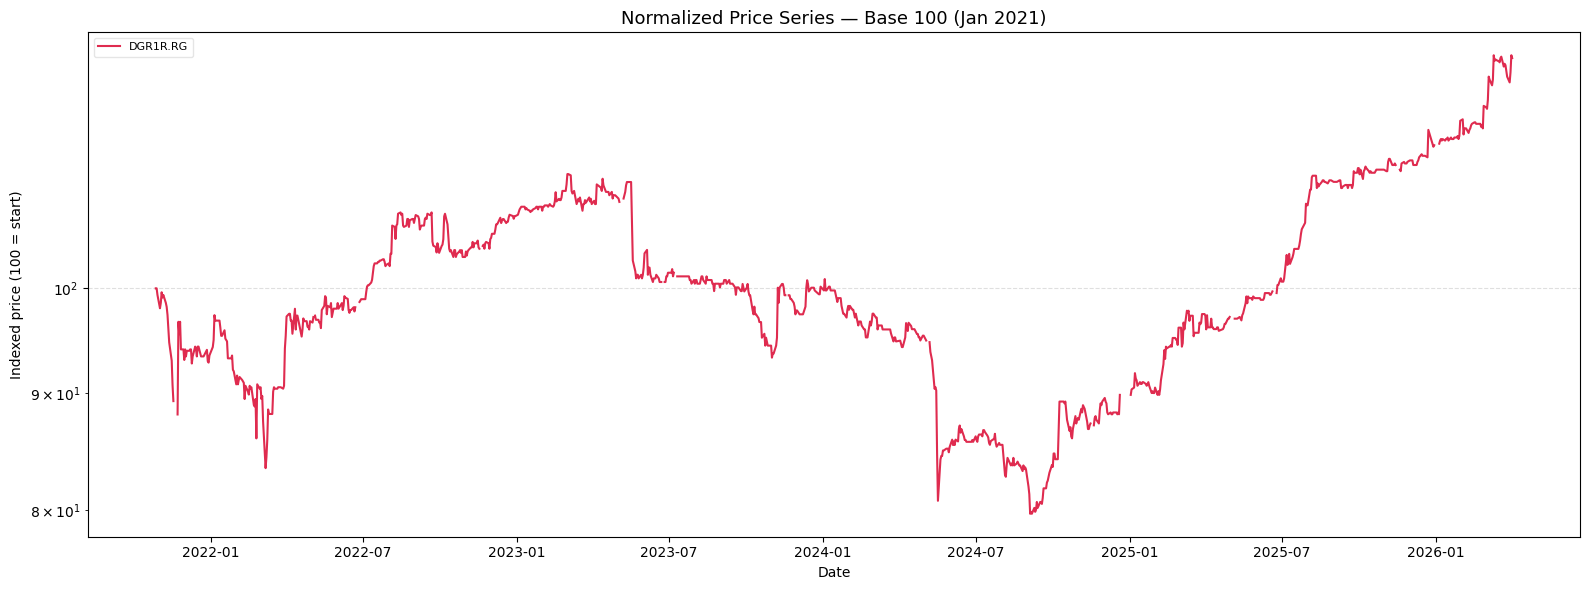

Top 5 performers (total % return):
MRK1T.TL    294.0
APG1L.VS    234.5
AKO1L.VS    158.8
GRG1L.VS    114.5
CPA1T.TL    106.8
Name: 2026-04-02 00:00:00, dtype: float64

Bottom 5 performers:
EFT1T.TL    30.1
DGR1R.RG    26.1
HAE1T.TL    16.3
NCN1T.TL   -41.8
NTU1L.VS   -70.6
Name: 2026-04-02 00:00:00, dtype: float64


In [ ]:
# backward fill to handle NaNs at start, then index to 100 at
normalized = df.div(df.bfill().iloc[0]) * 100  

fig, ax = plt.subplots(figsize=(16, 6))
for col in normalized.columns:
    ax.plot(normalized.index, normalized[col], linewidth=1, alpha=0.75, label=col)

ax.set_title("Normalized Price Series — Base 100 (Jan 2021)", fontsize=13)
ax.set_ylabel("Indexed price (100 = start)")
ax.set_xlabel("Date")
ax.legend(loc="upper left", ncol=3, fontsize=8, framealpha=0.5)
ax.set_yscale("log")  # log scale keeps fast movers from drowning out slow ones
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Top/bottom performers
total_return = (normalized.iloc[-1] - 100).sort_values(ascending=False)
print("Top 5 performers (total % return):")
print(total_return.head(5).round(1))
print("\nBottom 5 performers:")
print(total_return.tail(5).round(1))

### 3c. Individual Price Series (Small Multiples)

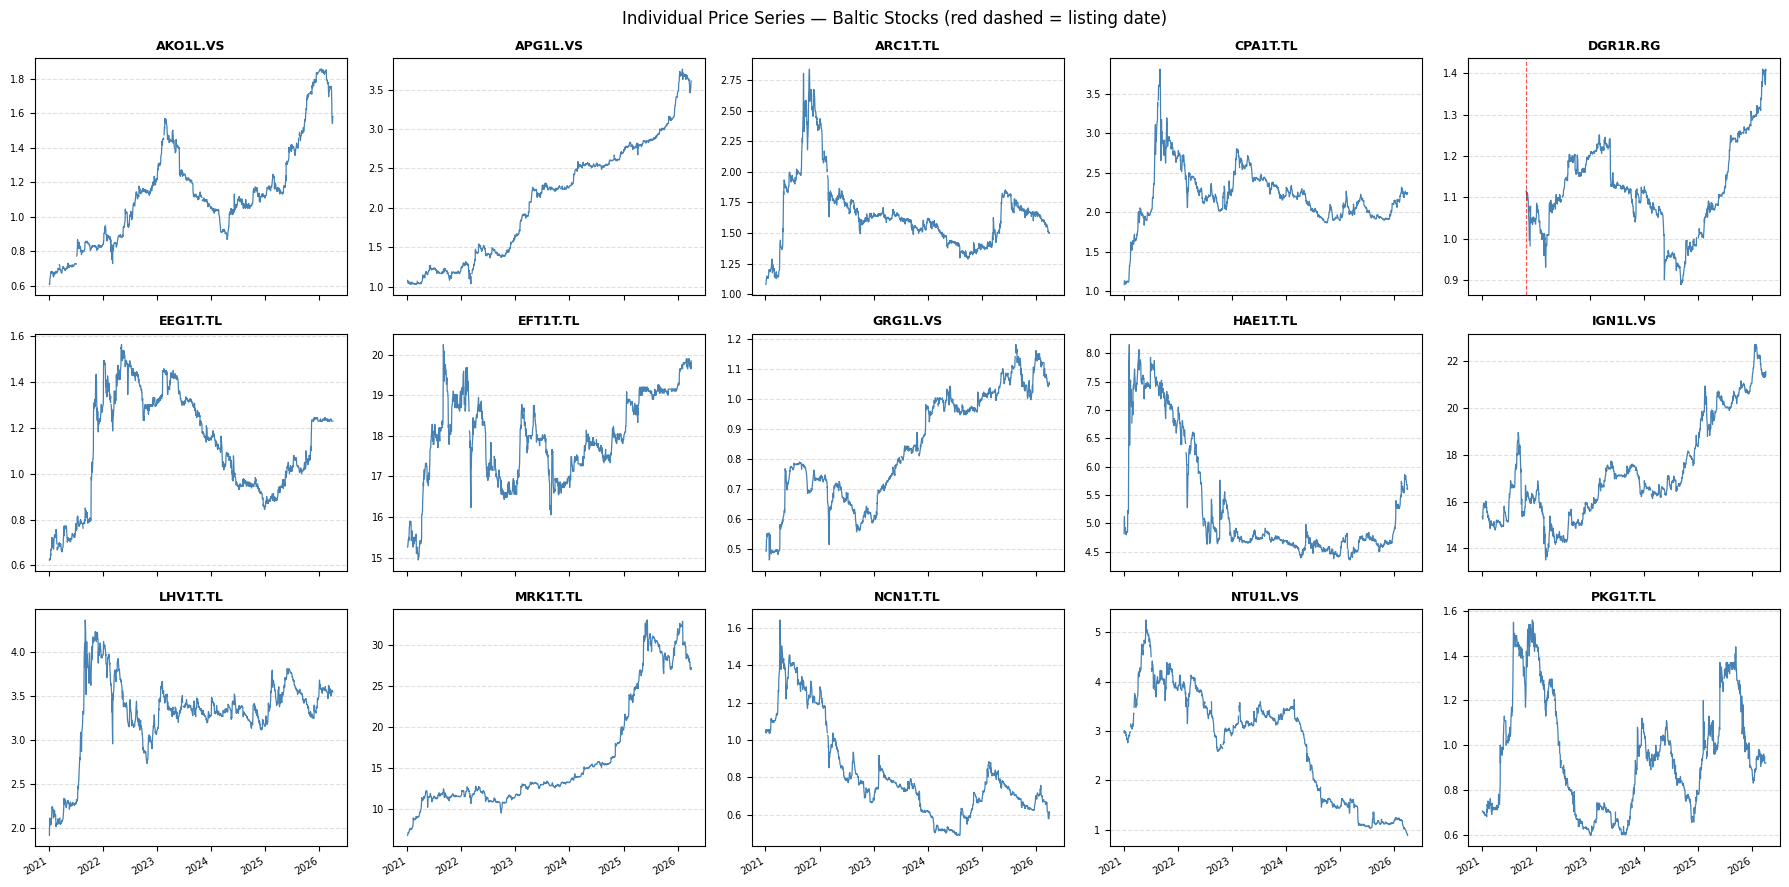

In [68]:
tickers = df.columns.tolist()
fig, axes = plt.subplots(3, 5, figsize=(18, 9), sharex=True)
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    ax.plot(df.index, df[ticker], linewidth=0.9, color="steelblue")
    ax.set_title(ticker, fontsize=9, fontweight="bold")
    ax.tick_params(labelsize=7)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    # Mark first valid date if ticker has leading NaNs
    first_valid = df[ticker].first_valid_index()
    if first_valid != df.index[0]:
        ax.axvline(first_valid, color="red", linewidth=0.8, linestyle="--", alpha=0.7)

fig.suptitle("Individual Price Series — Baltic Stocks (red dashed = listing date)", fontsize=12)
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()